In [6]:
import torch
import torch.nn.functional as F
from transformers import AutoTokenizer, AutoModelForCausalLM
import math
import numpy as np

In [7]:
device = "cuda" if torch.cuda.is_available() else "cpu"

In [8]:
def load_tokenizer_and_model(model_id: str, device=device, dtype=None):
    tokenizer = AutoTokenizer.from_pretrained(model_id, use_fast=True)
    model_kwargs = {}
    if dtype is not None:
        model_kwargs["torch_dtype"] = dtype
    model = AutoModelForCausalLM.from_pretrained(model_id, **model_kwargs)
    model.to(device)
    model.eval()
    return tokenizer, model

In [9]:
model_id = "/speech/dbwork/mul/spielwiese3/llm_project/llm_models/pre-trained/Meta-Llama-3-8b/"
tokenizer, model = load_tokenizer_and_model(model_id, device=device)

# sample sequence: "Hello world !"
prompt = "Dogs are considered to be our best friends."
toks = tokenizer(prompt, return_tensors="pt")
input_ids = toks.input_ids  # (1, L)
print("Initial tokens:", tokenizer.decode(input_ids[0]))
orig_ids = input_ids.clone().detach()
# flip some of the tokens
position = (3, 4)  # last token (0-based)
input_ids[0, position[0]:position[1]] = 2000#torch.randint_like(input_ids[0, position[0]:position[1]], 0, 30000)
print("Distorted tokens:", tokenizer.decode(input_ids[0]))

Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

Initial tokens: <|begin_of_text|>Dogs are considered to be our best friends.
Distorted tokens: <|begin_of_text|>Dogsfor considered to be our best friends.


In [10]:
alpha_grid = np.logspace(-4, 0, 50)  # adjust range if needed
ground_truth_token_id = orig_ids[0, position[0]].item()

In [11]:
ground_truth_token_id, input_ids[0, position[0]].item()

(527, 2000)

In [12]:
tokenizer.decode([int(ground_truth_token_id)], skip_special_tokens=True)

' are'

In [13]:
tokenizer.decode([int(input_ids[0, position[0]].item())], skip_special_tokens=True)

'for'

In [15]:
emb_layer = model.get_input_embeddings()
emb_matrix = emb_layer.weight.detach().to(device)

# Initialize continuous token s
with torch.no_grad():
    base_embs = emb_layer(input_ids.to(device))

In [25]:
import torch
import numpy as np
import torch.nn.functional as F


def compute_q_logprob(token_emb, theta, grad, alpha):
    """
    Computes unnormalized log q(x | theta, alpha)
    using Equation (1) from the paper.
    """
    m = theta + 0.5 * alpha * grad
    diff = token_emb - m
    dist2 = (diff * diff).sum()
    return - dist2 / (2 * alpha)


def run_dlp_with_gt_alpha(
        model,
        input_ids,
        orig_ids,
        position,
        steps=30,
        alpha_grid=np.logspace(-4, -1, 50),
):
    device = next(model.parameters()).device
    emb_matrix = model.get_input_embeddings().weight.detach()   # (V, D)
    vocab_size, emb_dim = emb_matrix.shape

    # Ground truth embedding
    gt_id = orig_ids[0, position[0]].item()
    emb_gt = emb_matrix[gt_id]

    # Initialize continuous θ₀ (start with GT + noise)
    theta = emb_gt.clone() + 0.05 * torch.randn_like(emb_gt)
    theta = theta.detach().requires_grad_(True)

    alpha_schedule = []
    chosen_tokens = []
    theta_states = []
    all_gt_logprobs = []

    for t in range(steps):

        # ------------------------------------------------------------------
        # 1. Compute gradient of log prob wrt θ_t
        # ------------------------------------------------------------------
        theta_emb = theta.unsqueeze(0).unsqueeze(0)
        base = model.get_input_embeddings()(input_ids).clone()
        base[:, position[0]:position[1], :] = theta_emb
        base.requires_grad_(True)

        out = model(inputs_embeds=base)
        logits = out.logits[:, :-1]
        targets = input_ids[:, 1:]

        # Joint log-likelihood
        loss = F.cross_entropy(
            logits.reshape(-1, logits.size(-1)),
            targets.reshape(-1),
            reduction="sum",
        )
        logp = -loss
        grad = torch.autograd.grad(logp, base)[0][0, position[0]].detach()

        # ------------------------------------------------------------------
        # 2. Pick α* that maximizes probability of the GT token
        # ------------------------------------------------------------------
        gt_logprobs = []
        
        for alpha in alpha_grid:
            lp = compute_q_logprob(emb_gt, theta.detach(), grad, alpha)
            gt_logprobs.append(lp.item())

        assert len(gt_logprobs) == len(alpha_grid)
        
        # Normalize each step's logprob row BEFORE adding to matrix
        row = np.array(gt_logprobs.copy())
        row = (row - row.min()) / (row.max() - row.min() + 1e-12)
        all_gt_logprobs.append(row)

        gt_logprobs = np.array(gt_logprobs)
        best_idx = np.argmax(gt_logprobs)
        alpha_star = alpha_grid[best_idx]
        alpha_schedule.append(alpha_star)
        

        print(f"[Step {t}] α* = {alpha_star:.6f}")




        # ------------------------------------------------------------------
        # 3. Using α*, compute q for all tokens and choose next x_{t+1}
        # ------------------------------------------------------------------
        with torch.no_grad():
            m = theta + 0.5 * alpha_star * grad
            diffs = emb_matrix - m.unsqueeze(0)     # (V, D)
            dist2 = (diffs * diffs).sum(dim=1)      # (V,)
            q_vals = - dist2 / (2 * alpha_star)

            next_token_id = torch.argmax(q_vals).item()
            chosen_tokens.append(next_token_id)
            emb_x_next = emb_matrix[next_token_id]

            # pick the token with highest q
            next_token = tokenizer.decode([next_token_id], skip_special_tokens=True)
        
            print(f"Chosen token at step {t}: '{next_token}'")
            top_n = 5
            indices = torch.argsort(q_vals, dim=0, descending=True)[:5]
            print(f"Top 5 tokens are: ")
            for it in indices:
                print(tokenizer.decode([it], skip_special_tokens=True))

        # ------------------------------------------------------------------
        # 4. Update θ_{t+1} using DLP update rule
        # ------------------------------------------------------------------
        theta_next = 0.5 * ((theta + 0.5 * alpha_star * grad) + emb_x_next)
        theta = theta_next.detach().requires_grad_(True)

        # Store trajectory
        theta_states.append(theta.detach().cpu().numpy())
        

    return np.array(alpha_schedule), chosen_tokens, np.array(theta_states), gt_logprobs, np.array(all_gt_logprobs)


In [26]:
# ============================================================
# 3. Plotting helpers
# ============================================================

def plot_alpha_schedule(alpha_schedule):
    plt.figure(figsize=(7,4))
    plt.plot(alpha_schedule, marker='o')
    plt.title("Optimal α Schedule (chosen by GT probability)")
    plt.xlabel("Step")
    plt.ylabel("α*")
    plt.grid(True)
    plt.show()


def plot_heatmap(all_gt_logprobs, alpha_grid):
    all_gt_logprobs = np.array(all_gt_logprobs)

    plt.figure(figsize=(8,6))
    plt.imshow(all_gt_logprobs, aspect='auto', cmap="viridis")
    plt.colorbar(label="log q(GT | θ, α)")
    plt.xlabel("α index")
    plt.ylabel("Step")
    plt.xticks(
        ticks=[0, len(alpha_grid)//2, len(alpha_grid)-1],
        labels=[f"{alpha_grid[0]:.1e}", f"{alpha_grid[len(alpha_grid)//2]:.1e}", f"{alpha_grid[-1]:.1e}"]
    )
    plt.title("Heatmap of GT Log-Probability across α Grid")
    plt.show()



Initial tokens: <|begin_of_text|>Dogs are considered to be our best friends.
Distorted tokens: <|begin_of_text|>Dogsfor considered to be our best friends.
Original Token which was distorted:  are
[Step 0] α* = 0.064980
Chosen token at step 0: ' are'
Top 5 tokens are: 
 are
 Are
 is
 ARE
 were
[Step 1] α* = 0.303982
Chosen token at step 1: ' are'
Top 5 tokens are: 
 are
 is
 were
 Are
 ARE
[Step 2] α* = 0.271546
Chosen token at step 2: ' are'
Top 5 tokens are: 
 are
 is
 were
 Are
 ARE
[Step 3] α* = 0.008486
Chosen token at step 3: ' are'
Top 5 tokens are: 
 are
 is
 were
 ARE
 have
[Step 4] α* = 0.002962
Chosen token at step 4: ' are'
Top 5 tokens are: 
 are
 is
 were
 Are
 was
[Step 5] α* = 0.000100
Chosen token at step 5: ' are'
Top 5 tokens are: 
 are
 is
 were
 Are
 was
[Step 6] α* = 0.004057
Chosen token at step 6: ' are'
Top 5 tokens are: 
 are
 is
 were
 was
lardı
[Step 7] α* = 0.000884
Chosen token at step 7: ' are'
Top 5 tokens are: 
 are
 is
 were
ımda
lardı
[Step 8] α* = 0.0

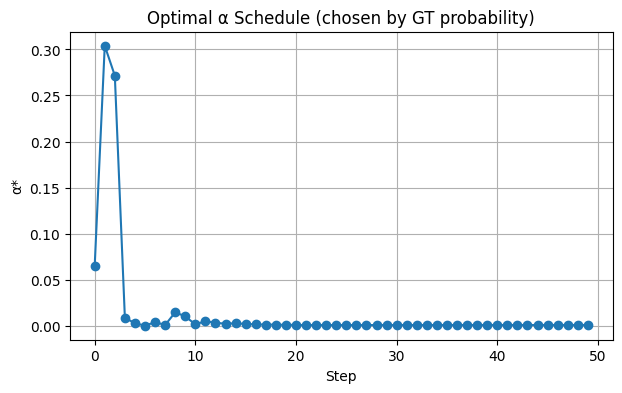

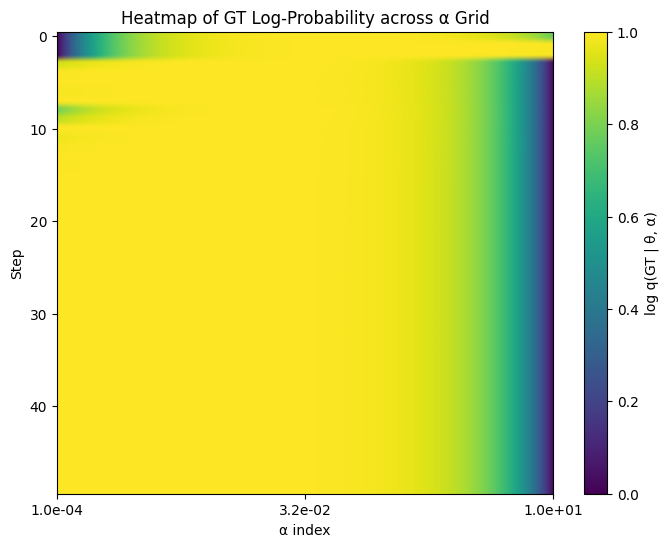

In [45]:
# ---- Load model ----

model.to(device)
model.eval()

# ---- Input prompt ----
prompt = "Dogs are considered to be our best friends."
toks = tokenizer(prompt, return_tensors="pt").to(device)
input_ids = toks.input_ids  # (1, L)
print("Initial tokens:", tokenizer.decode(input_ids[0]))
orig_ids = input_ids.clone().detach()
# flip some of the tokens
position = (3, 4)  # last token (0-based)
input_ids[0, position[0]:position[1]] = 2000#torch.randint_like(input_ids[0, position[0]:position[1]], 0, 30000)
print("Distorted tokens:", tokenizer.decode(input_ids[0]))
orig_tok = tokenizer.decode([orig_ids[0, position[0]:position[1]].item()])
print(f"Original Token which was distorted: {orig_tok}")
# Select a corrupted position (example)
# position = 3  # token index to optimize (0-based)
alpha_grid = np.logspace(-4, 1, 10000)  # adjust range if needed
# ---- Run the method ----
alpha_schedule, chosen_tokens, theta_states, heatmap_data, all_h = run_dlp_with_gt_alpha(
    model=model,
    input_ids=input_ids,
    orig_ids=orig_ids,
    position=position,
    steps=50,
    alpha_grid=alpha_grid
)

# ---- Print results ----
print("\nChosen α schedule:", alpha_schedule)
print("\nChosen tokens:", chosen_tokens)

# ---- Show plots ----
# plot_alpha_schedule(alpha_schedule)
# plot_heatmap(all_h, alpha_grid)

In [46]:
def plot_heatmap_and_schedule(all_gt_logprobs, alpha_grid, alpha_schedule):
    import numpy as np
    import matplotlib.pyplot as plt

    # Convert list[list] -> array
    gt_mat = np.array(all_gt_logprobs).T
    # shape: (len(alpha_grid), num_steps)

    num_alphas, num_steps = gt_mat.shape

    plt.figure(figsize=(10, 7))

    # Show heatmap
    img = plt.imshow(
        gt_mat,
        aspect='auto',
        cmap="viridis",
        origin="lower",
        # vmin=gt_mat.min(),
        # vmax=gt_mat.max()
        # vmin=0.0,
        # vmax=1.0     # because we normalized
    )

    plt.colorbar(label="Normalized log q(GT | θ, α)")

    plt.ylabel("α")
    plt.xlabel("Time step")

    # Fix axes so they never autoscale
    # plt.xlim(0, num_steps - 1)
    # plt.ylim(0, num_alphas - 1)

    # Y ticks as readable alpha values
    yticks = np.linspace(0, num_alphas - 1, 8, dtype=int)
    plt.yticks(yticks, [f"{alpha_grid[i]:.1e}" for i in yticks])

    # Compute α index schedule
    alpha_idx_schedule = [
        np.argmin(np.abs(alpha_grid - a)) for a in alpha_schedule
    ]

    # Make sure schedule is inside bounds
    alpha_idx_schedule = np.clip(alpha_idx_schedule, 0, num_alphas - 1)

    # Plot schedule line
    plt.plot(
        np.arange(num_steps),
        alpha_idx_schedule,
        color="white",
        linewidth=2,
        label="Optimal α*(t)"
    )

    plt.legend()
    plt.title(f"Normalized GT Log-Probability Heatmap + Optimal α Schedule | Token: '{orig_tok}'")

    plt.show()


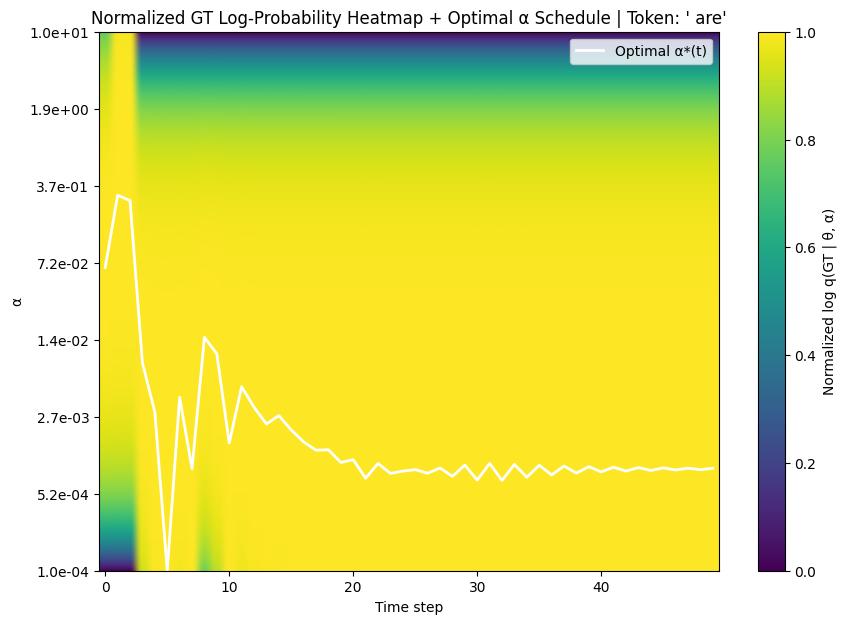

In [47]:
plot_heatmap_and_schedule(all_h, alpha_grid, alpha_schedule)